[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__XGBoost__](./05.1_Divvy_modeling_xgboost.ipynb) | [__RNN__](./05.2_Divvy_modeling_rnn.ipynb) | [__ARIMAX__](./05.3_Divvy_modeling_arimax.ipynb) | [__Ensemble__](./05.4_Divvy_modeling_ensemble.ipynb) | [__Home__](../README.md)

# Divvy: Bike Sharing Forecast
## Forecasting

__Dataset:__ [Divvy Data](https://divvybikes.com/system-data) \
__Author:__ [Dmitry Luchkin](https://www.linkedin.com/in/dmitry-luchkin/) \
__Date:__ May 2025

> **Attention**
>
> The data utilized in this project were sourced from the official public data provided by Divvy. All analysis, results, and insights presented in this notebook were conducted and formulated by Dmitry Luchkin. I declare that I am not affiliated with Divvy, Lyft, the City of Chicago, or any associated organizations. The views and interpretations expressed herein are solely my own and do not represent the positions or policies of these entities.

### Notebooks <a class="anchor" name='notebooks'></a>

+ [Initial Data Exploration](./01_Divvy_data_exploration.ipynb)
+ [Data Cleaning](./02_Divvy_data_cleaning.ipynb)
+ [Exploratory Data Analysis](./03_Divvy_exploratory_data_analysis.ipynb)
+ [Feature Engineering](./04_Divvy_feature_engineering.ipynb)
+ Modeling & Validation:
  - [XGBoost: Modeling & Validation](./05.1_Divvy_modeling_xgboost.ipynb)
  - [RNN: Modeling & Validation](./05.2_Divvy_modeling_rnn.ipynb)
  - [ARIMAX: Modeling & Validation](./05.3_Divvy_modeling_arimax.ipynb)
  - [Ensemble: Modeling & Validation](./05.4_Divvy_modeling_ensemble.ipynb)
+ __[Forecasting](./06_Divvy_forecasting.ipynb)__

### Import Libraries <a name='import-libraries'></a>

In [1]:
import os 
import sys
import pickle
import warnings

import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series

from pmdarima import auto_arima

warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
sys.path.append('../02_scripts/')

# import project code
from utils.plotting import notebook_setup
from utils.plotting.notebook_setup import TRAIN_COLOR, TEST_COLOR, FORECAST_COLOR
from utils.plotting.viz import plot_trips, distplot, check_residuals, plot_window_size
from utils.model.tools import load_dump

### Loading Data <a name='loading-data'></a>

In [3]:
train_filename = "../00_data/02_processed/divvy_train.pkl"
test_filename = "../00_data/02_processed/divvy_test.pkl"
train = None
test = None
# load training set
with open(train_filename, 'rb') as f:
        train = pickle.load(f)

# load test set
with open(test_filename, 'rb') as f:
        test = pickle.load(f)

#### Daily number of trips by bike type and user type

In [18]:
casual_regular_bike = pd.Series(pd.concat([train["casual_regular_bike"], 
                                           test["casual_regular_bike"]], axis=0), 
                                index=train.index.append(test.index))

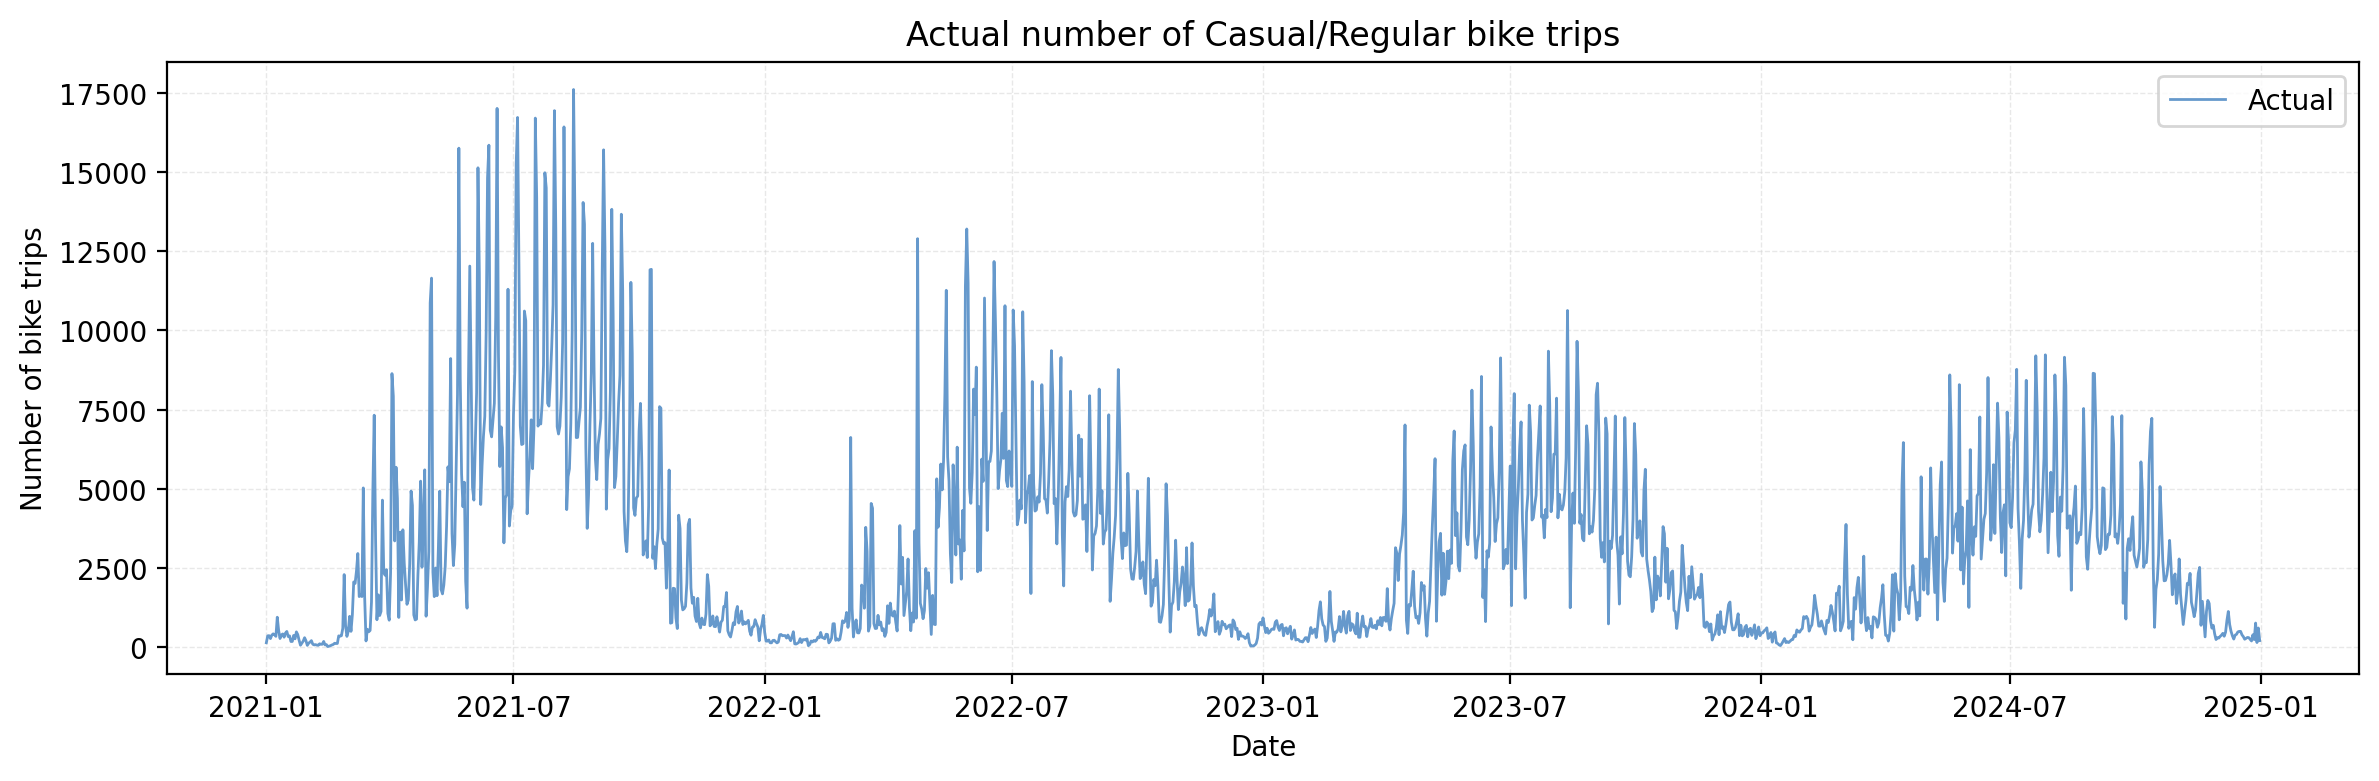

In [20]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.plot(casual_regular_bike, lw=1, color=TRAIN_COLOR, label="Actual")
plt.title("Actual number of Casual/Regular bike trips")
plt.xlabel("Date")
plt.ylabel("Number of bike trips")
plt.legend()
plt.grid(linestyle='--', color="lightgray")
plt.tight_layout()
plt.show()

In [26]:
# xgboost dump
xgboost_models_dump = load_dump("../03_models/01_xgboost/xgboost_models_dump.pkl")
# rnn dump
rnn_models_dump = load_dump("../03_models/02_rnn/rnn_models_dump.pkl")
# harimax dump
harimax_models_dump = load_dump("../03_models/03_arimax/arimax_models_dump.pkl")
# ensemble
ensemble_dump = load_dump("../03_models/04_ensemble/ensemble_models_dump.pkl")


---
\
[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__XGBoost__](./05.1_Divvy_modeling_xgboost.ipynb) | [__RNN__](./05.2_Divvy_modeling_rnn.ipynb) | [__ARIMAX__](./05.3_Divvy_modeling_arimax.ipynb) | [__Ensemble__](./05.4_Divvy_modeling_ensemble.ipynb) | [__Home__](../README.md)

\
\
Divvy: Bike Sharing Forecast, _May 2025_